# DD2 PPO Training Dashboard

Notebook для запуска долгого обучения, сохранения лучшей модели, оценки и построения графиков. Запускай его из корня проекта или просто открой этот файл в Jupyter/VS Code: первая кодовая ячейка сама выставит `PROJECT_ROOT`.

Основные артефакты пишутся в отдельную папку `runs/<RUN_NAME>/`, чтобы smoke и долгие прогоны не перетирали друг друга.

In [10]:
import json
import os
from pathlib import Path
import subprocess
import sys
from datetime import datetime

try:
    from IPython.display import display
except ImportError:
    display = print

# Heavy plotting/data imports are loaded lazily in metric cells.
np = None
pd = None
plt = None

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'scripts' / 'train.py').is_file():
    PROJECT_ROOT = Path.cwd().parent
assert (PROJECT_ROOT / 'scripts' / 'train.py').is_file(), f'Project root not found from {Path.cwd()}'
os.chdir(PROJECT_ROOT)

PYTHON = PROJECT_ROOT / '.venv' / 'Scripts' / 'python.exe'
if not PYTHON.is_file():
    PYTHON = Path(sys.executable)

print('PROJECT_ROOT =', PROJECT_ROOT)
print('PYTHON       =', PYTHON)

PROJECT_ROOT = d:\RL DD
PYTHON       = d:\RL DD\.venv\Scripts\python.exe


## Конфигурация

Для основного запуска сейчас используется `TOTAL_STEPS = 10_000_000`. Для пробного запуска можно временно поставить `100_000`.

In [11]:
RUN_NAME = 'dd2_ppo_10m_v1'
TOTAL_STEPS = 10_000_000
SEED = 123
DEVICE = 'cuda'  # cuda, cpu, auto

N_ENVS = 16
N_STEPS = 2048
BATCH_SIZE = 1024
N_EPOCHS = 6
LEARNING_RATE = 2.5e-4
LR_END_RATIO = 0.08
ENT_COEF = 0.01
GAMMA = 0.995
NET_ARCH = '512,512'
MAX_EPISODE_STEPS = 120

EVAL_GLOBAL_FREQ = 100_000
CHECKPOINT_GLOBAL_FREQ = 250_000
MILESTONE_CHECKPOINTS = '10000000'

RUN_DIR = PROJECT_ROOT / 'runs' / RUN_NAME
BEST_DIR = RUN_DIR / 'best'
EVAL_DIR = RUN_DIR / 'eval'
CHECKPOINT_DIR = RUN_DIR / 'checkpoints'
FIG_DIR = RUN_DIR / 'figures'
FINAL_MODEL = RUN_DIR / 'final_model.zip'
META_JSON = RUN_DIR / 'run_meta.json'
EVAL_JSON = RUN_DIR / 'holdout_eval.json'

for path in (RUN_DIR, BEST_DIR, EVAL_DIR, CHECKPOINT_DIR, FIG_DIR):
    path.mkdir(parents=True, exist_ok=True)

config = {
    'run_name': RUN_NAME,
    'total_steps': TOTAL_STEPS,
    'seed': SEED,
    'device': DEVICE,
    'n_envs': N_ENVS,
    'n_steps': N_STEPS,
    'batch_size': BATCH_SIZE,
    'n_epochs': N_EPOCHS,
    'learning_rate': LEARNING_RATE,
    'lr_end_ratio': LR_END_RATIO,
    'ent_coef': ENT_COEF,
    'gamma': GAMMA,
    'net_arch': NET_ARCH,
    'max_episode_steps': MAX_EPISODE_STEPS,
    'eval_global_freq': EVAL_GLOBAL_FREQ,
    'checkpoint_global_freq': CHECKPOINT_GLOBAL_FREQ,
    'milestone_checkpoints': MILESTONE_CHECKPOINTS,
    'created_at': datetime.now().isoformat(timespec='seconds'),
}
(RUN_DIR / 'notebook_config.json').write_text(json.dumps(config, ensure_ascii=False, indent=2), encoding='utf-8')
config

{'run_name': 'dd2_ppo_10m_v1',
 'total_steps': 10000000,
 'seed': 123,
 'device': 'cuda',
 'n_envs': 16,
 'n_steps': 2048,
 'batch_size': 1024,
 'n_epochs': 6,
 'learning_rate': 0.00025,
 'lr_end_ratio': 0.08,
 'ent_coef': 0.01,
 'gamma': 0.995,
 'net_arch': '512,512',
 'max_episode_steps': 120,
 'eval_global_freq': 100000,
 'checkpoint_global_freq': 250000,
 'milestone_checkpoints': '10000000',
 'created_at': '2026-05-05T06:15:36'}

## Запуск обучения

Эта ячейка стримит лог обучения прямо в вывод ноутбука. Лучшая модель eval callback будет сохранена в `RUN_DIR / best / best_model.zip`, финальная модель - в `RUN_DIR / final_model.zip`.

In [12]:
train_cmd = [
    str(PYTHON), 'scripts/train.py',
    '--steps', str(TOTAL_STEPS),
    '--seed', str(SEED),
    '--n-envs', str(N_ENVS),
    '--device', DEVICE,
    '--learning-rate', str(LEARNING_RATE),
    '--lr-end-ratio', str(LR_END_RATIO),
    '--ent-coef', str(ENT_COEF),
    '--net-arch', NET_ARCH,
    '--n-steps', str(N_STEPS),
    '--batch-size', str(BATCH_SIZE),
    '--n-epochs', str(N_EPOCHS),
    '--gamma', str(GAMMA),
    '--max-episode-steps', str(MAX_EPISODE_STEPS),
    '--eval-global-freq', str(EVAL_GLOBAL_FREQ),
    '--checkpoint-global-freq', str(CHECKPOINT_GLOBAL_FREQ),
    '--checkpoint-save-path', str(CHECKPOINT_DIR),
    '--milestone-checkpoints', MILESTONE_CHECKPOINTS,
    '--best-model-save-path', str(BEST_DIR),
    '--eval-log-path', str(EVAL_DIR),
    '--out', str(FINAL_MODEL),
    '--run-meta-out', str(META_JSON),
]

print(' '.join(train_cmd))
process = subprocess.Popen(
    train_cmd,
    cwd=PROJECT_ROOT,
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True,
    bufsize=1,
)
for line in process.stdout or []:
    print(line, end='')
return_code = process.wait()
print('train_return_code =', return_code)
if return_code != 0:
    raise RuntimeError(f'Training failed with code {return_code}')

d:\RL DD\.venv\Scripts\python.exe scripts/train.py --steps 10000000 --seed 123 --n-envs 16 --device cuda --learning-rate 0.00025 --lr-end-ratio 0.08 --ent-coef 0.01 --net-arch 512,512 --n-steps 2048 --batch-size 1024 --n-epochs 6 --gamma 0.995 --max-episode-steps 120 --eval-global-freq 100000 --checkpoint-global-freq 250000 --checkpoint-save-path d:\RL DD\runs\dd2_ppo_10m_v1\checkpoints --milestone-checkpoints 10000000 --best-model-save-path d:\RL DD\runs\dd2_ppo_10m_v1\best --eval-log-path d:\RL DD\runs\dd2_ppo_10m_v1\eval --out d:\RL DD\runs\dd2_ppo_10m_v1\final_model.zip --run-meta-out d:\RL DD\runs\dd2_ppo_10m_v1\run_meta.json
training_device=cuda
Using cuda device
Logging to runs/tb/MaskablePPO_3
d:\RL DD\.venv\Lib\site-packages\stable_baselines3\common\callbacks.py:419: UserWarning: Training and eval env are not of the same type<stable_baselines3.common.vec_env.subproc_vec_env.SubprocVecEnv object at 0x0000021C82053C20> != <stable_baselines3.common.vec_env.dummy_vec_env.DummyVecE

## Проверка сохраненной модели

Проверяем размерность observation/action space у лучшей модели. Для текущей тренировочной среды ожидается `obs=(240,)`, `action=Discrete(43)`.

In [13]:
best_model = BEST_DIR / 'best_model.zip'
model_for_eval = best_model if best_model.is_file() else FINAL_MODEL
print('model_for_eval =', model_for_eval)

check_cmd = [
    str(PYTHON), '-c',
    "from sb3_contrib import MaskablePPO; import sys; m=MaskablePPO.load(sys.argv[1]); print('obs', m.observation_space); print('action', m.action_space)",
    str(model_for_eval),
]
subprocess.run(check_cmd, cwd=PROJECT_ROOT, check=True)

model_for_eval = d:\RL DD\runs\dd2_ppo_10m_v1\best\best_model.zip


CompletedProcess(args=['d:\\RL DD\\.venv\\Scripts\\python.exe', '-c', "from sb3_contrib import MaskablePPO; import sys; m=MaskablePPO.load(sys.argv[1]); print('obs', m.observation_space); print('action', m.action_space)", 'd:\\RL DD\\runs\\dd2_ppo_10m_v1\\best\\best_model.zip'], returncode=0)

## Holdout evaluation

Оценка на holdout encounters с несколькими seeds. JSON с подробностями пишется в папку запуска.

In [14]:
EVAL_EPISODES = 200
EVAL_SEEDS = '17,27,37'

eval_cmd = [
    str(PYTHON), 'scripts/evaluate.py',
    '--model', str(model_for_eval),
    '--episodes', str(EVAL_EPISODES),
    '--seeds', EVAL_SEEDS,
    '--out-json', str(EVAL_JSON),
]
print(' '.join(eval_cmd))
subprocess.run(eval_cmd, cwd=PROJECT_ROOT, check=True)

d:\RL DD\.venv\Scripts\python.exe scripts/evaluate.py --model d:\RL DD\runs\dd2_ppo_10m_v1\best\best_model.zip --episodes 200 --seeds 17,27,37 --out-json d:\RL DD\runs\dd2_ppo_10m_v1\holdout_eval.json


CompletedProcess(args=['d:\\RL DD\\.venv\\Scripts\\python.exe', 'scripts/evaluate.py', '--model', 'd:\\RL DD\\runs\\dd2_ppo_10m_v1\\best\\best_model.zip', '--episodes', '200', '--seeds', '17,27,37', '--out-json', 'd:\\RL DD\\runs\\dd2_ppo_10m_v1\\holdout_eval.json'], returncode=0)

## Графики eval callback

`MaskableEvalCallback` пишет `evaluations.npz`. Здесь строятся mean reward и mean episode length по eval-точкам.

saved d:\RL DD\runs\dd2_ppo_10m_v1\figures\eval_callback.png


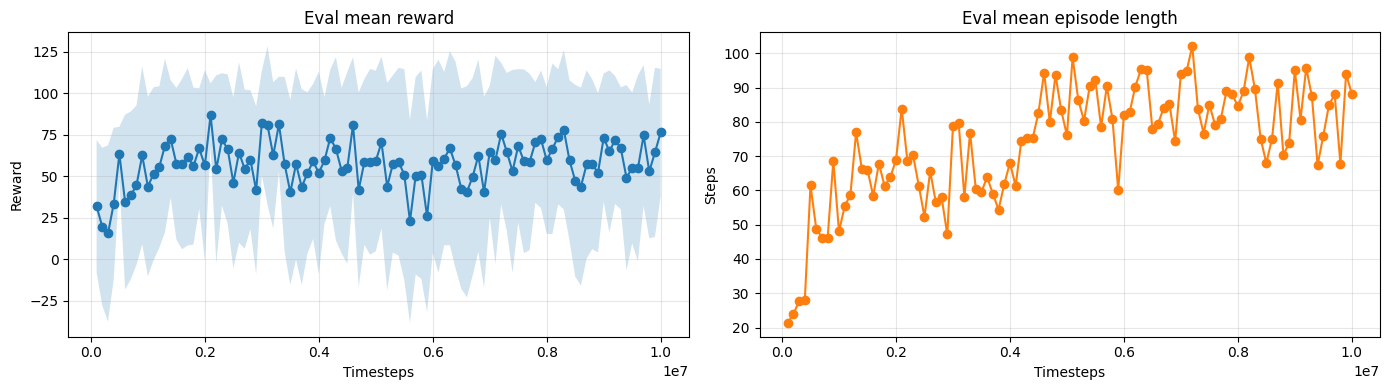

In [15]:
global np, pd, plt
if np is None:
    import numpy as np
if pd is None:
    try:
        import pandas as pd
    except ImportError:
        pd = None
if plt is None:
    import matplotlib.pyplot as plt

def plot_eval_npz(eval_npz: Path):
    if plt is None:
        raise ImportError('matplotlib is not installed')
    data = np.load(eval_npz)
    timesteps = data['timesteps']
    results = data['results']
    ep_lengths = data['ep_lengths']
    mean_reward = results.mean(axis=1)
    std_reward = results.std(axis=1)
    mean_length = ep_lengths.mean(axis=1)

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    axes[0].plot(timesteps, mean_reward, marker='o')
    axes[0].fill_between(timesteps, mean_reward - std_reward, mean_reward + std_reward, alpha=0.2)
    axes[0].set_title('Eval mean reward')
    axes[0].set_xlabel('Timesteps')
    axes[0].set_ylabel('Reward')
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(timesteps, mean_length, marker='o', color='tab:orange')
    axes[1].set_title('Eval mean episode length')
    axes[1].set_xlabel('Timesteps')
    axes[1].set_ylabel('Steps')
    axes[1].grid(True, alpha=0.3)

    fig.tight_layout()
    out = FIG_DIR / 'eval_callback.png'
    fig.savefig(out, dpi=160)
    print('saved', out)
    return fig

eval_npz = EVAL_DIR / 'evaluations.npz'
if eval_npz.is_file():
    plot_eval_npz(eval_npz)
else:
    print('No evaluations.npz found:', eval_npz)

## Графики holdout metrics

Строит win rate, reward, survival и episode length по каждому holdout encounter из JSON, созданного `scripts/evaluate.py`.

summary = {'win_rate': 0.695, 'mean_reward': 59.13682259259256, 'mean_steps': 64.48166666666667, 'survival_rate': 0.74625}
saved d:\RL DD\runs\dd2_ppo_10m_v1\figures\holdout_metrics.png


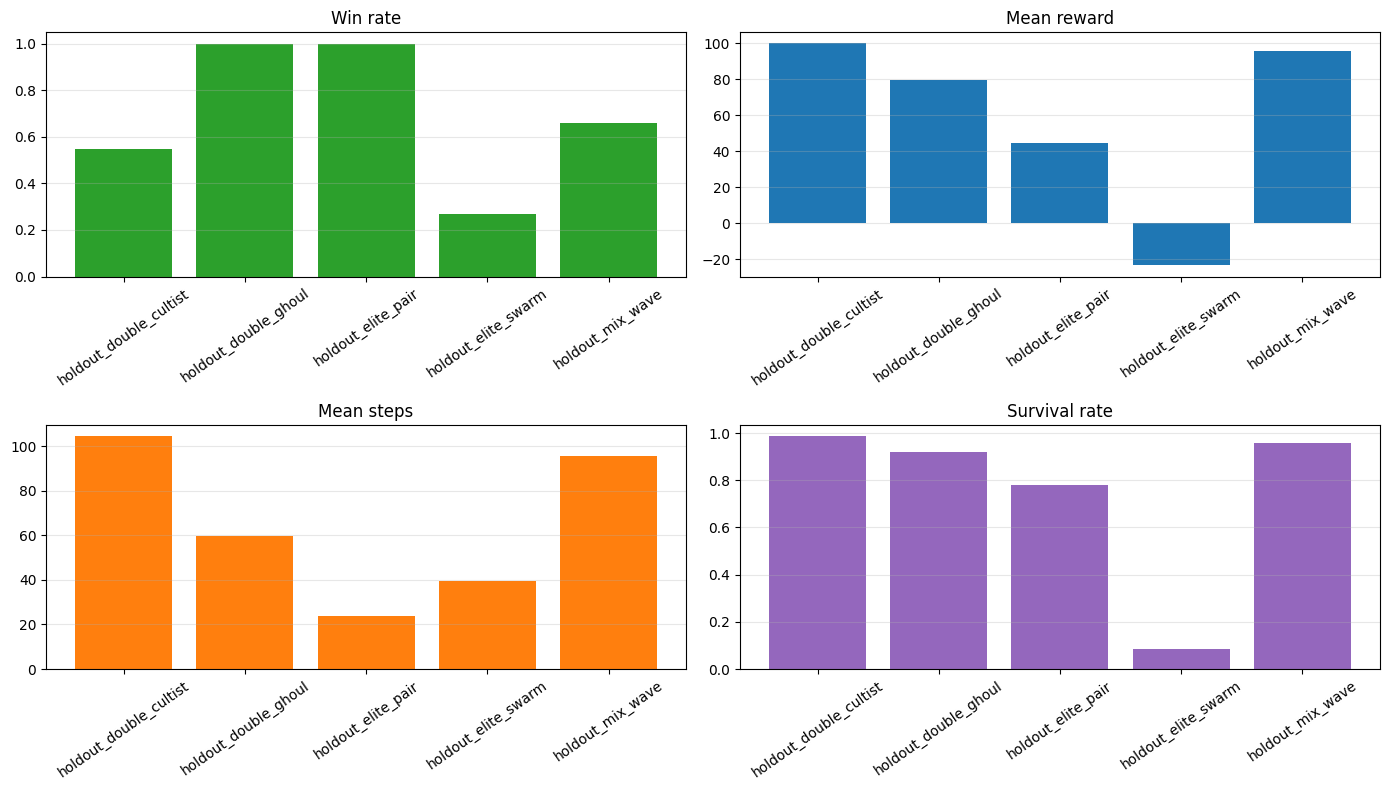

In [16]:
global pd, plt
if pd is None:
    try:
        import pandas as pd
    except ImportError:
        pd = None
if plt is None:
    import matplotlib.pyplot as plt

def plot_holdout_json(path: Path):
    if plt is None:
        raise ImportError('matplotlib is not installed')
    raw = json.loads(path.read_text(encoding='utf-8'))
    rows = []
    for encounter_id, row in raw.get('encounters', {}).items():
        rows.append({'encounter': encounter_id, **row})
    if not rows:
        print('No encounter rows in', path)
        return None
    if pd is not None:
        df = pd.DataFrame(rows).sort_values('encounter')
    else:
        df = rows

    encounters = list(df['encounter']) if pd is not None else [r['encounter'] for r in df]
    win_rate = list(df['win_rate']) if pd is not None else [r['win_rate'] for r in df]
    mean_reward = list(df['mean_reward']) if pd is not None else [r['mean_reward'] for r in df]
    mean_steps = list(df['mean_steps']) if pd is not None else [r['mean_steps'] for r in df]
    survival_rate = list(df['survival_rate']) if pd is not None else [r['survival_rate'] for r in df]

    fig, axes = plt.subplots(2, 2, figsize=(14, 8))
    axes = axes.ravel()
    series = [
        ('Win rate', win_rate, 'tab:green'),
        ('Mean reward', mean_reward, 'tab:blue'),
        ('Mean steps', mean_steps, 'tab:orange'),
        ('Survival rate', survival_rate, 'tab:purple'),
    ]
    for ax, (title, values, color) in zip(axes, series):
        ax.bar(encounters, values, color=color)
        ax.set_title(title)
        ax.tick_params(axis='x', rotation=35)
        ax.grid(True, axis='y', alpha=0.3)
    fig.tight_layout()
    out = FIG_DIR / 'holdout_metrics.png'
    fig.savefig(out, dpi=160)
    print('summary =', raw.get('summary'))
    print('saved', out)
    return fig

if EVAL_JSON.is_file():
    plot_holdout_json(EVAL_JSON)
else:
    print('No holdout JSON found:', EVAL_JSON)

## TensorBoard scalars

Если установлен `tensorboard`, эта ячейка читает event-файлы и строит train/eval scalars. Если графиков не хватает, можно открыть TensorBoard отдельно:

```powershell
.\.venv\Scripts\tensorboard.exe --logdir runs\tb
```

loaded TensorBoard dir: d:\RL DD\runs\tb\MaskablePPO_3
scalar tags: ['eval/mean_ep_length', 'eval/mean_reward', 'time/fps', 'train/approx_kl', 'train/clip_fraction', 'train/clip_range', 'train/entropy_loss', 'train/explained_variance', 'train/learning_rate', 'train/loss', 'train/policy_gradient_loss', 'train/value_loss']
saved d:\RL DD\runs\dd2_ppo_10m_v1\figures\tb_losses.png
saved d:\RL DD\runs\dd2_ppo_10m_v1\figures\tb_policy.png
saved d:\RL DD\runs\dd2_ppo_10m_v1\figures\tb_eval.png


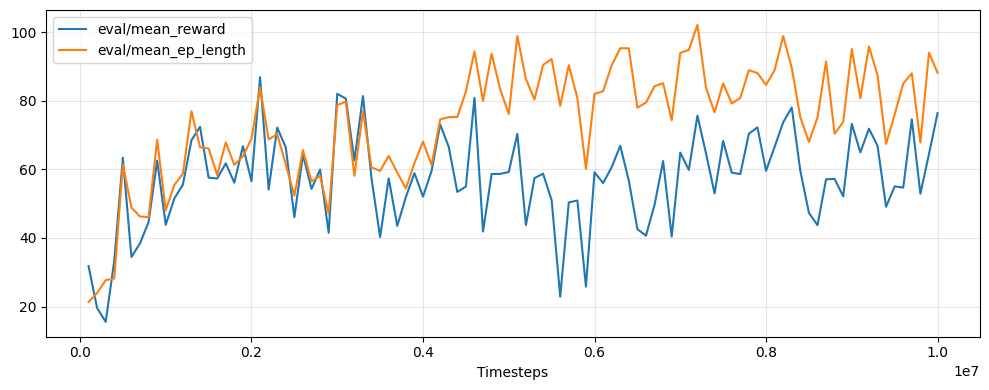

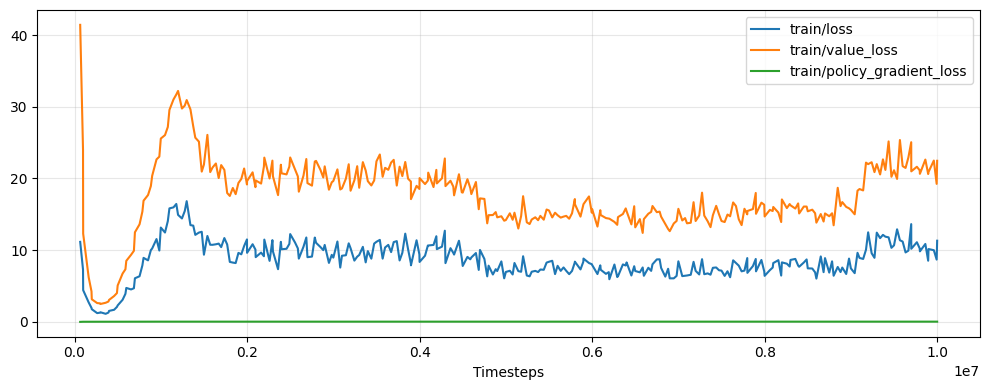

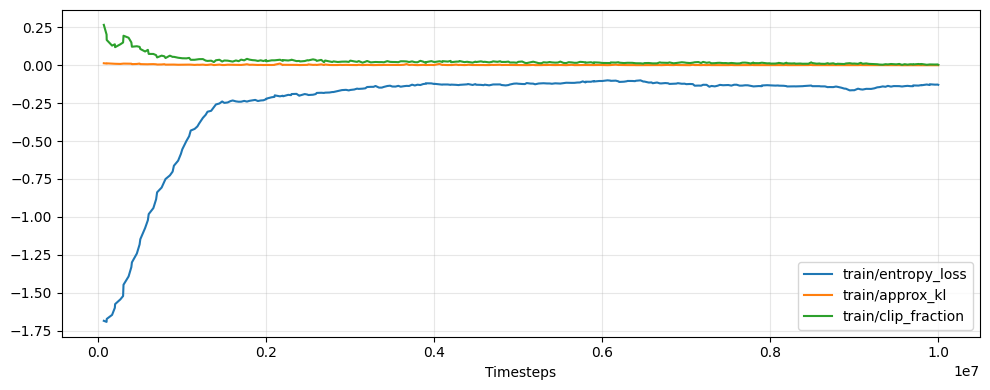

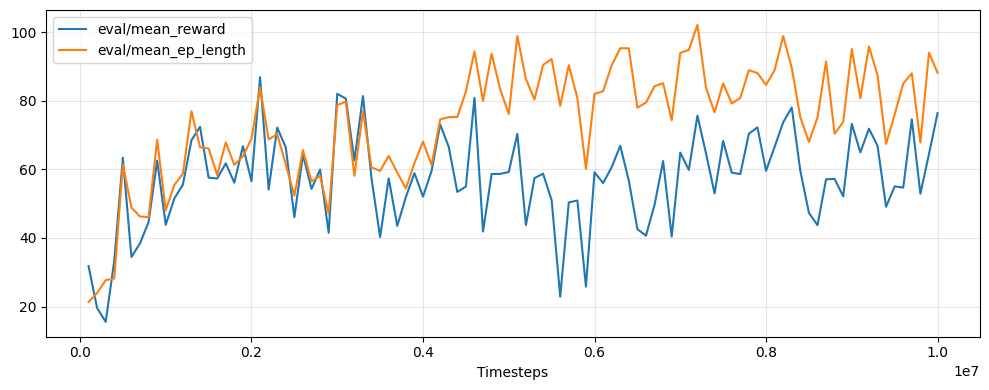

In [17]:
global pd, plt
if pd is None:
    try:
        import pandas as pd
    except ImportError:
        pd = None
if plt is None:
    import matplotlib.pyplot as plt

def load_tensorboard_scalars(log_root: Path):
    try:
        from tensorboard.backend.event_processing.event_accumulator import EventAccumulator
    except ImportError:
        print('tensorboard is not installed; skipping scalar plots')
        return {}
    event_files = sorted(log_root.rglob('events.out.tfevents.*'), key=lambda p: p.stat().st_mtime)
    if not event_files:
        print('No TensorBoard event files found under', log_root)
        return {}
    newest_dir = event_files[-1].parent
    acc = EventAccumulator(str(newest_dir))
    acc.Reload()
    out = {}
    for tag in acc.Tags().get('scalars', []):
        events = acc.Scalars(tag)
        out[tag] = [(e.step, e.value) for e in events]
    print('loaded TensorBoard dir:', newest_dir)
    print('scalar tags:', sorted(out))
    return out

def plot_scalar_group(scalars: dict, tags: list[str], filename: str):
    if plt is None or not scalars:
        return None
    fig, ax = plt.subplots(figsize=(10, 4))
    for tag in tags:
        if tag not in scalars:
            continue
        xs, ys = zip(*scalars[tag])
        ax.plot(xs, ys, label=tag)
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_xlabel('Timesteps')
    fig.tight_layout()
    out = FIG_DIR / filename
    fig.savefig(out, dpi=160)
    print('saved', out)
    return fig

scalars = load_tensorboard_scalars(PROJECT_ROOT / 'runs' / 'tb')
plot_scalar_group(scalars, ['train/loss', 'train/value_loss', 'train/policy_gradient_loss'], 'tb_losses.png')
plot_scalar_group(scalars, ['train/entropy_loss', 'train/approx_kl', 'train/clip_fraction'], 'tb_policy.png')
plot_scalar_group(scalars, ['eval/mean_reward', 'eval/mean_ep_length'], 'tb_eval.png')

## Диагностика распределения действий

Проверяет, что маски не пустеют, эпизоды завершаются, `move/pass/skill/item` доступны и модель не уходит в бесконечные pass/move циклы.

In [18]:
diagnostic_code = r'''
from collections import Counter
from agents.ppo_agent import PPOAgent
from env.dd_env import DarkestDungeonEnv

model_path = r"""__MODEL_PATH__"""
episodes = 100
env = DarkestDungeonEnv(seed=606)
agent = PPOAgent.load(model_path, env=env)
legal_counts = Counter()
chosen_counts = Counter()
terminal = Counter()
win_by_enc = Counter()
eps_by_enc = Counter()
remnant_seen = 0
invalid_masks = 0
total_steps = 0
encounters = ['holdout_double_ghoul','holdout_double_cultist','holdout_mix_wave','holdout_elite_pair','holdout_elite_swarm']
for ep in range(episodes):
    enc = encounters[ep % len(encounters)]
    obs, _ = env.reset(seed=606 + ep, options={'encounter_id': enc})
    done = False
    steps = 0
    info = {}
    while not done and steps < 180:
        legal = env.backend.legal_action_specs(env.state)
        for spec in legal:
            legal_counts[spec.kind] += 1
        mask = env.action_masks()
        invalid_masks += 0 if mask.any() else 1
        act, _ = agent.predict(obs, mask)
        spec = env._decode_action(act)
        chosen_counts[spec.kind] += 1
        obs, rew, term, trunc, info = env.step(act)
        remnant_seen += sum(1 for u in env.state.enemies if getattr(u, 'is_remnant', False))
        done = term or trunc
        steps += 1
        total_steps += 1
    eps_by_enc[enc] += 1
    if info.get('heroes_won'):
        win_by_enc[enc] += 1
    terminal['wins' if info.get('heroes_won') else 'loss_or_trunc'] += 1
    terminal['truncated' if not env.state.done else 'done'] += 1

print('total_steps', total_steps)
print('legal_counts', dict(legal_counts))
print('chosen_counts', dict(chosen_counts))
print('terminal', dict(terminal))
print('win_by_enc', {k: f'{win_by_enc[k]}/{eps_by_enc[k]}' for k in encounters})
print('remnant_seen_ticks', remnant_seen)
print('invalid_masks', invalid_masks)
print('obs_dim', env.observation_space.shape[0], 'action_n', env.action_space.n)
'''.replace('__MODEL_PATH__', str(model_for_eval))

diag_cmd = [str(PYTHON), '-c', diagnostic_code]
subprocess.run(diag_cmd, cwd=PROJECT_ROOT, check=True)

CompletedProcess(args=['d:\\RL DD\\.venv\\Scripts\\python.exe', '-c', '\nfrom collections import Counter\nfrom agents.ppo_agent import PPOAgent\nfrom env.dd_env import DarkestDungeonEnv\n\nmodel_path = r"""d:\\RL DD\\runs\\dd2_ppo_10m_v1\\best\\best_model.zip"""\nepisodes = 100\nenv = DarkestDungeonEnv(seed=606)\nagent = PPOAgent.load(model_path, env=env)\nlegal_counts = Counter()\nchosen_counts = Counter()\nterminal = Counter()\nwin_by_enc = Counter()\neps_by_enc = Counter()\nremnant_seen = 0\ninvalid_masks = 0\ntotal_steps = 0\nencounters = [\'holdout_double_ghoul\',\'holdout_double_cultist\',\'holdout_mix_wave\',\'holdout_elite_pair\',\'holdout_elite_swarm\']\nfor ep in range(episodes):\n    enc = encounters[ep % len(encounters)]\n    obs, _ = env.reset(seed=606 + ep, options={\'encounter_id\': enc})\n    done = False\n    steps = 0\n    info = {}\n    while not done and steps < 180:\n        legal = env.backend.legal_action_specs(env.state)\n        for spec in legal:\n            